# Exploratory Data Analysis — Student Depression Dataset

Goal: understand the dataset, identify data quality issues, and surface the strongest signals related to depression. Findings here drive the preprocessing in `02_preprocessing.ipynb`.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_raw
from src.visualization import (
    plot_numeric_distribution,
    plot_categorical_counts,
    plot_numeric_vs_target,
    plot_categorical_vs_target,
    plot_correlation_heatmap,
    save_fig,
)

df = load_raw()
df.shape

(27901, 18)

## 1. Sanity checks

In [2]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  str    
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  str    
 4   Profession                             27901 non-null  str    
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  str    
 11  Dietary Habit

In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

Duplicate rows: 0


In [5]:
print(df.describe(include="all").T)
print("\nTarget distribution:")
print(df["Depression"].value_counts(normalize=True).rename("share"))

                                         count unique                  top  \
id                                     27901.0    NaN                  NaN   
Gender                                   27901      2                 Male   
Age                                    27901.0    NaN                  NaN   
City                                     27901     52               Kalyan   
Profession                               27901     14              Student   
Academic Pressure                      27901.0    NaN                  NaN   
Work Pressure                          27901.0    NaN                  NaN   
CGPA                                   27901.0    NaN                  NaN   
Study Satisfaction                     27901.0    NaN                  NaN   
Job Satisfaction                       27901.0    NaN                  NaN   
Sleep Duration                           27901      5  'Less than 5 hours'   
Dietary Habits                           27901      4           

In [6]:
df["Profession"].value_counts()

Profession
Student                     27870
Architect                       8
Teacher                         6
'Digital Marketer'              3
'Content Writer'                2
Chef                            2
Doctor                          2
Pharmacist                      2
'Civil Engineer'                1
'UX/UI Designer'                1
'Educational Consultant'        1
Manager                         1
Lawyer                          1
Entrepreneur                    1
Name: count, dtype: int64

## 2. Univariate distributions

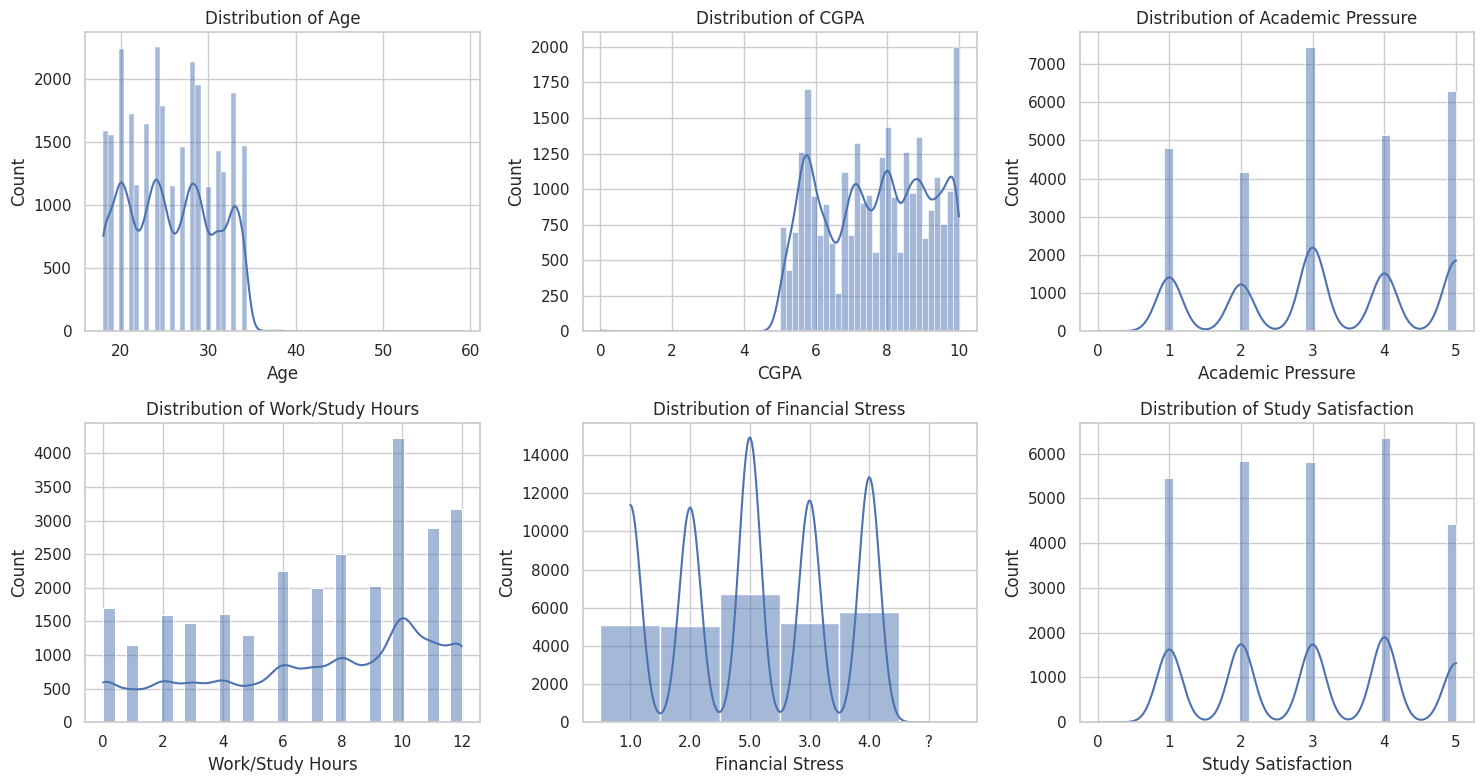

In [7]:
numeric_cols = ["Age", "CGPA", "Academic Pressure", "Work/Study Hours", "Financial Stress", "Study Satisfaction"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_cols):
    plot_numeric_distribution(df, col, ax=ax)
fig.tight_layout()
save_fig(fig, "01_numeric_distributions", figures_dir="../reports/figures")
plt.show()

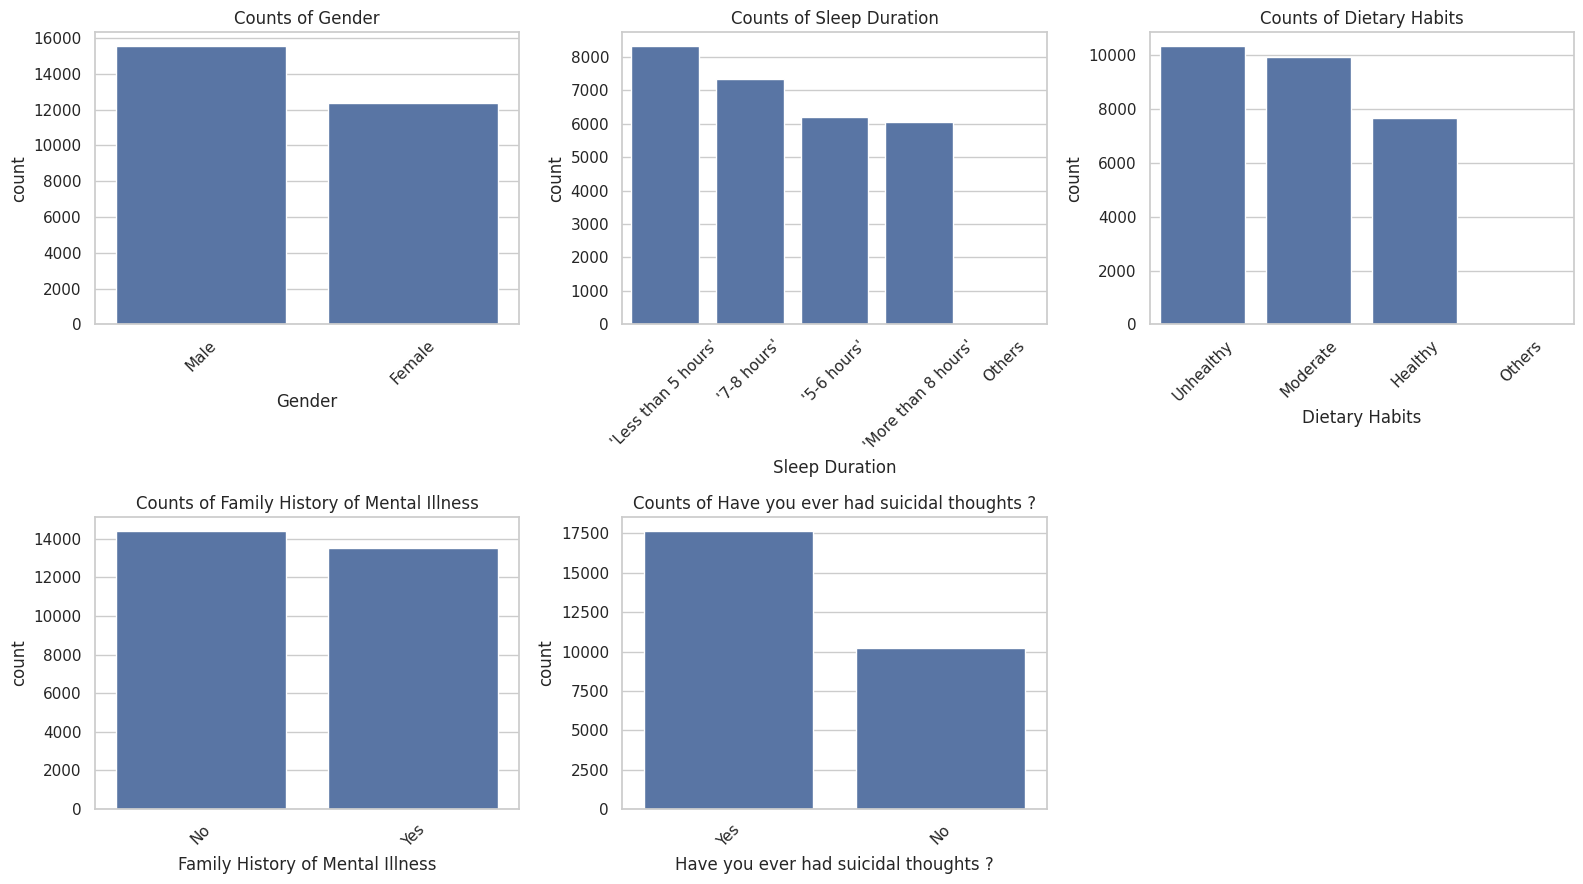

In [8]:
cat_cols = ["Gender", "Sleep Duration", "Dietary Habits", "Family History of Mental Illness",
            "Have you ever had suicidal thoughts ?"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_cols):
    plot_categorical_counts(df, col, ax=ax)
for ax in axes.flat[len(cat_cols):]:
    ax.axis("off")
fig.tight_layout()
save_fig(fig, "01_categorical_counts", figures_dir="../reports/figures")
plt.show()

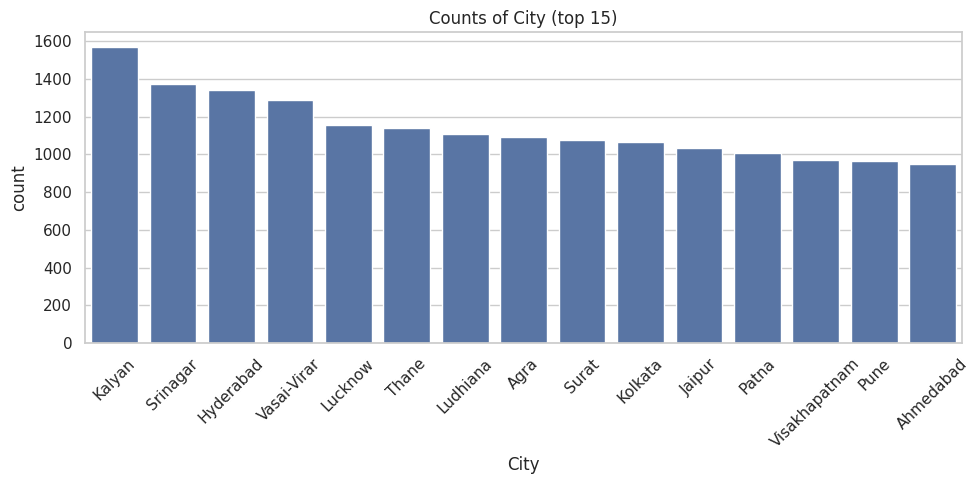

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_categorical_counts(df, "City", top_n=15, ax=ax)
fig.tight_layout()
save_fig(fig, "01_top_cities", figures_dir="../reports/figures")
plt.show()

## 3. Bivariate analysis vs Depression

/home/kuba/Projects/Student-Depression-Analysis/notebooks/../src/visualization.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=column, ax=ax, palette=PALETTE)
/home/kuba/Projects/Student-Depression-Analysis/notebooks/../src/visualization.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=column, ax=ax, palette=PALETTE)
/home/kuba/Projects/Student-Depression-Analysis/notebooks/../src/visualization.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=column, ax=ax, palette=P

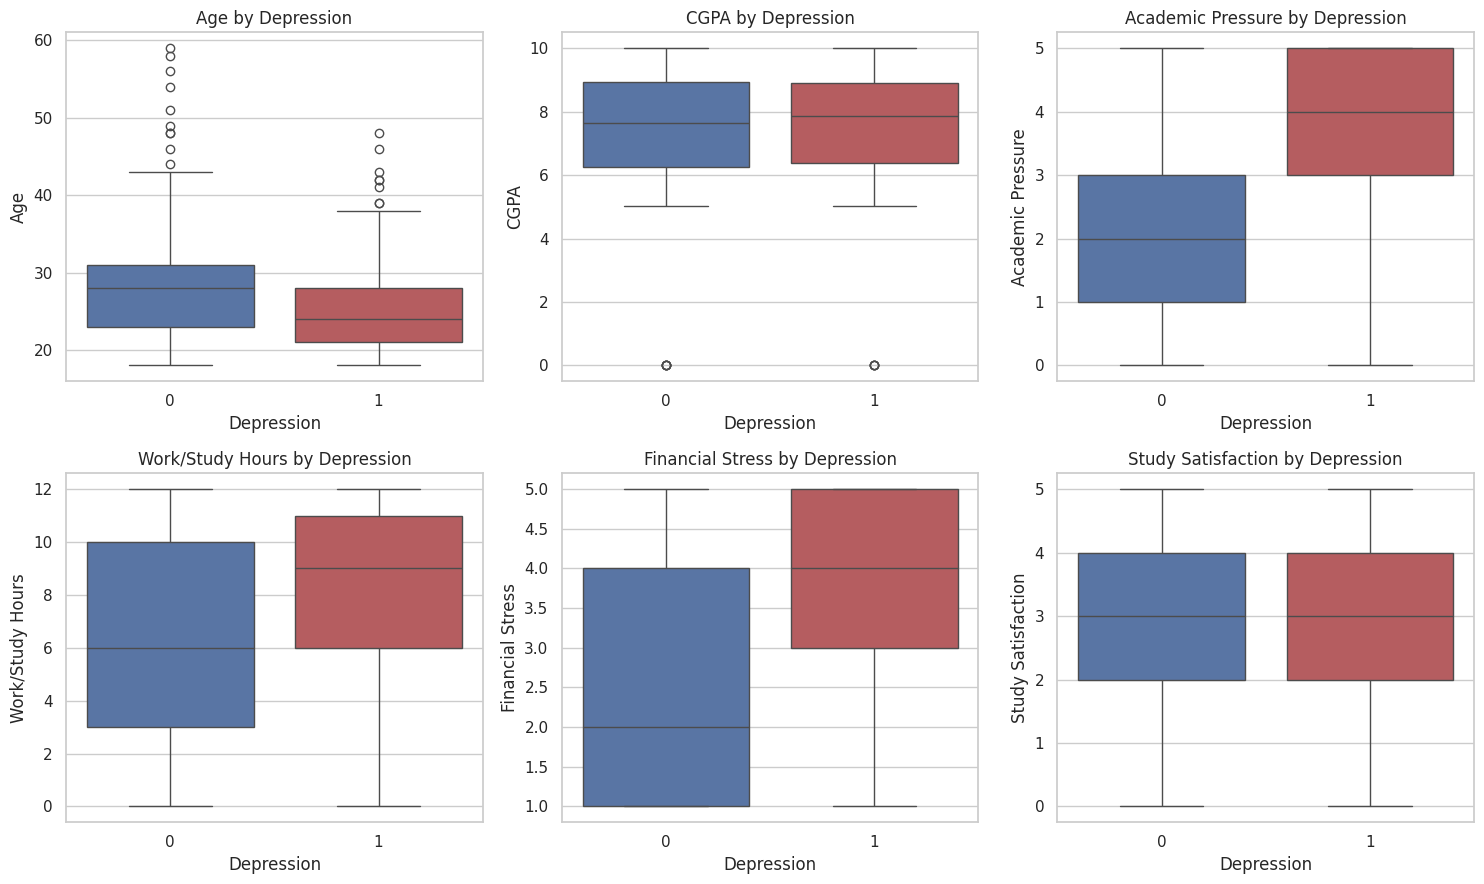

In [10]:
df["Financial Stress"] = pd.to_numeric(df["Financial Stress"], errors="coerce")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flat, numeric_cols):
    plot_numeric_vs_target(df, col, ax=ax)
fig.tight_layout()
save_fig(fig, "01_numeric_vs_target", figures_dir="../reports/figures")
plt.show()

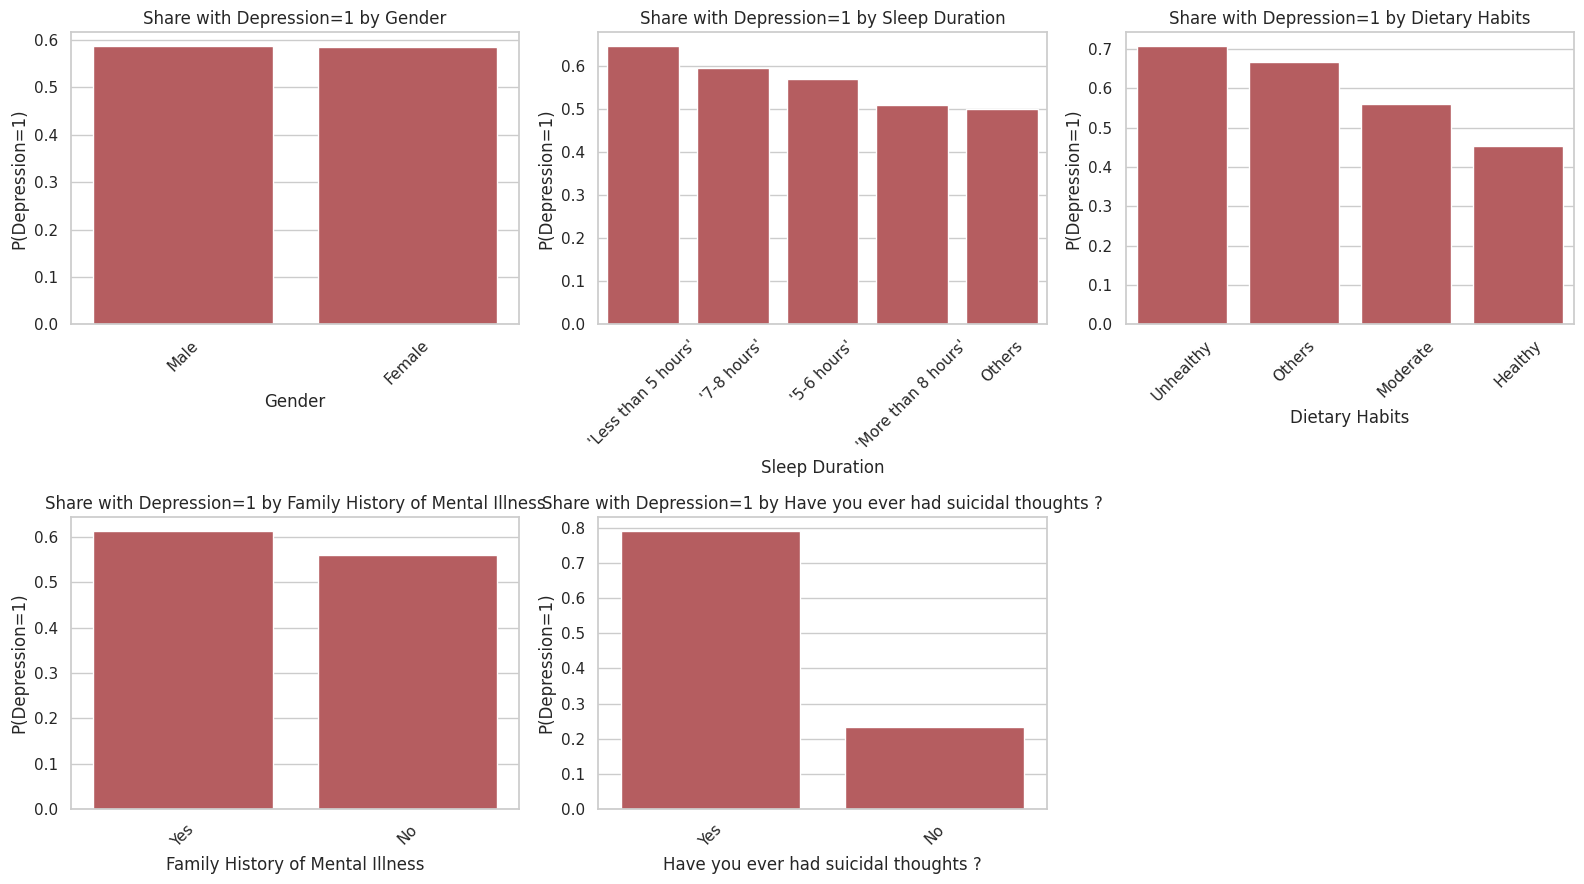

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_cols):
    plot_categorical_vs_target(df, col, ax=ax)
for ax in axes.flat[len(cat_cols):]:
    ax.axis("off")
fig.tight_layout()
save_fig(fig, "01_categorical_vs_target", figures_dir="../reports/figures")
plt.show()

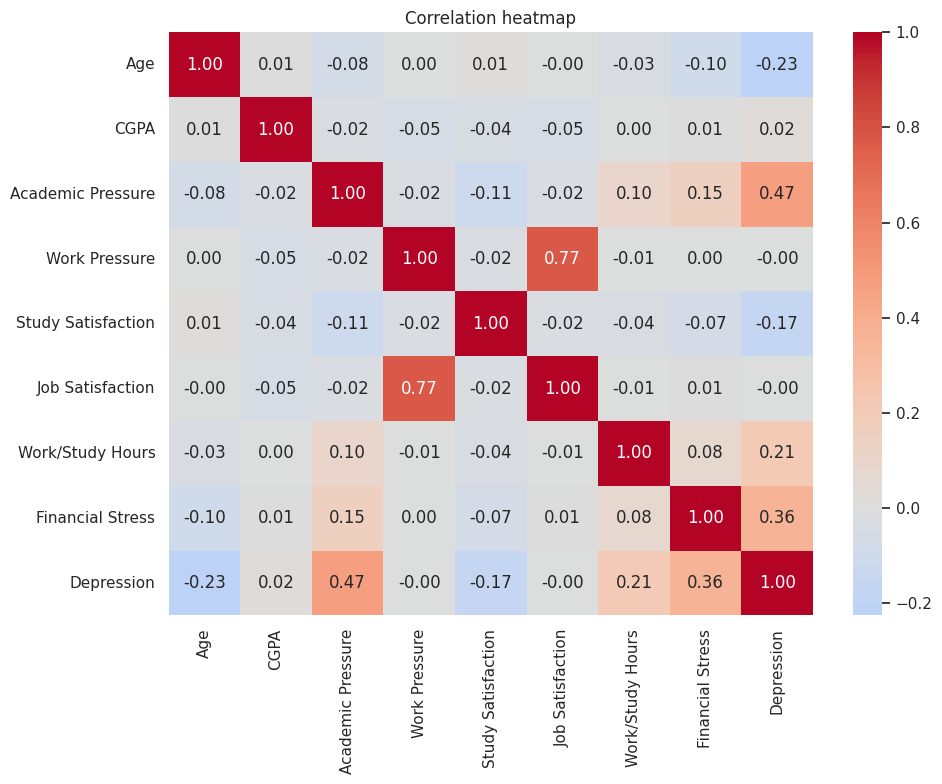

In [12]:
corr_cols = ["Age", "CGPA", "Academic Pressure", "Work Pressure", "Study Satisfaction",
             "Job Satisfaction", "Work/Study Hours", "Financial Stress", "Depression"]
fig, ax = plt.subplots(figsize=(10, 8))
plot_correlation_heatmap(df, corr_cols, ax=ax)
fig.tight_layout()
save_fig(fig, "01_correlation_heatmap", figures_dir="../reports/figures")
plt.show()

Depression                                    0         1
Have you ever had suicidal thoughts ?                    
No                                     0.767789  0.232211
Yes                                    0.209504  0.790496


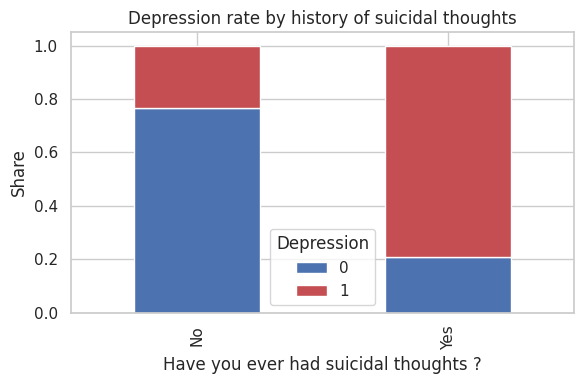

In [13]:
ct = pd.crosstab(df["Have you ever had suicidal thoughts ?"], df["Depression"], normalize="index")
print(ct)
fig, ax = plt.subplots(figsize=(6, 4))
ct.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Depression rate by history of suicidal thoughts")
ax.set_ylabel("Share")
fig.tight_layout()
save_fig(fig, "01_suicidal_vs_depression", figures_dir="../reports/figures")
plt.show()

## 4. Conclusions from EDA

1. Target balance: `Depression=1` shares roughly 58.5% of records (41.5% `Depression=0`) -> moderately balanced, no need for class-weight tricks but worth confirming with stratified CV.
2. `Have you ever had suicidal thoughts ?` is the dominant single predictor: depression rate is ~79% among respondents who answered "Yes" vs ~23% among "No" -- categorical encoding to binary is essential.
3. `Academic Pressure`, `Financial Stress`, and `Work/Study Hours` show the strongest numeric separation between classes.
4. `CGPA` and `Job Satisfaction` show weaker signal; `Job Satisfaction` is near-zero because the dataset is almost entirely students (27,870 of 27,901 rows).
5. `Sleep Duration` is ordinal-looking (`<5h`, `5-6h`, `7-8h`, `>8h`) -- encode as ordinal, not one-hot.
6. `City` has high cardinality (52 unique values); rare cities should be grouped into `Other` to control feature dimensionality.
7. No `NaN` missing values in any column; however `Financial Stress` contains 3 rows with the sentinel string `"?"` (out of 27,901) that must be coerced to numeric / imputed during preprocessing.

These observations drive the encoding choices in `02_preprocessing.ipynb`.